In [9]:
import sys
import os

# Obtener el directorio padre (ruta base del proyecto)
base_path = os.path.abspath('..')
if base_path not in sys.path:
    sys.path.append(base_path)

import paths
import pandas as pd
import matplotlib.pyplot as plt
import modos_color
import segmentacion
import numpy as np

## Rutas del proyecto
data_dir = paths.data_dir()
avance3_base = paths.fase3_segmentacion_dir()

# imagenes seleccionadas para cambio de color
sel_img_path = os.path.join(avance3_base, "imagenes_prueba.csv")
sel_img_df = pd.read_csv(sel_img_path)

In [10]:
segmentacion = segmentacion.Segmentacion()

In [11]:
imagenes_rgb = {}
for idx, row in sel_img_df.iterrows():
    img_name = row["ruta_imagen"]
    img_num = row["dificultad"]
    img_path = os.path.join(data_dir, img_name)
    
    # Leer la imagen
    R, G, B = modos_color.read_image_by_channels(img_path)
    imagenes_rgb[img_num] = (R, G, B)

In [12]:
imagenes_grises = {}
for img_num, (R, G, B) in imagenes_rgb.items():
    # Convertir a escala de grises
    gris = modos_color.rgb_to_gris(R, G, B)
    imagenes_grises[img_num] = gris

In [13]:
def aplicar_filtro_por_canal(canales, filtro_fn, **kwargs):
    '''
    Aplica un filtro de escala de grises a cada canal de forma independiente.

    Params:
        canales   : tuple de arrays 2D numpy (un array por canal)
        filtro_fn : función que recibe un array 2D y retorna un array 2D
                    Ejemplos: cv2.GaussianBlur, cv2.medianBlur,
                              skimage.filters.gaussian, tu propio filtro
        **kwargs  : parámetros adicionales que recibe filtro_fn

    Retorna:
        tuple de canales filtrados, misma estructura que la entrada
    '''
    return tuple(filtro_fn(canal.astype(np.float32), **kwargs)
                 for canal in canales)

In [14]:
import filtros

img_prepro = {}
preprocesamiento = filtros.Filtrado_Espacio()
# Para cada imagen en escala de grises, aplicar un filtro de suavizado
for img_num, gris in imagenes_grises.items():
    suave = preprocesamiento.adaptive_local_noise_filter(gris, noise_variance=0.1, kernel_size=7)
    realce = preprocesamiento.clahe(suave, clip_limit=2.0, tile_grid_size=(8, 8), n_bins=256)
    img_prepro[img_num] = realce

In [15]:
# A cada imagen preprocesada, aplicar el filtro de otsu
img_otsu = {}
for img_num, prepro in img_prepro.items():
    otsu = segmentacion.otsu_simple(prepro, L=256)
    img_otsu[img_num] = otsu

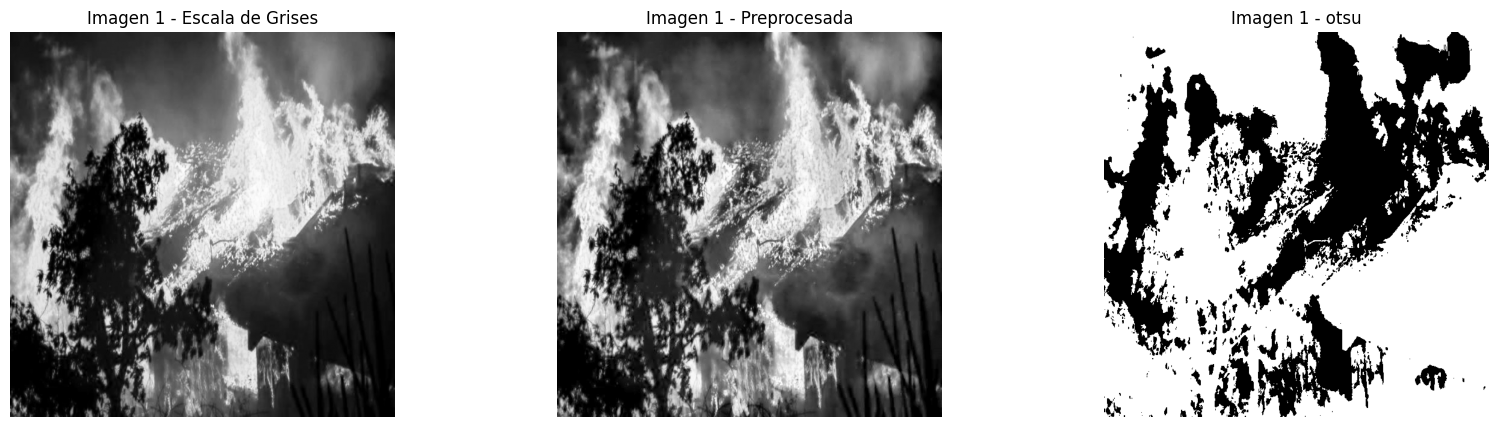

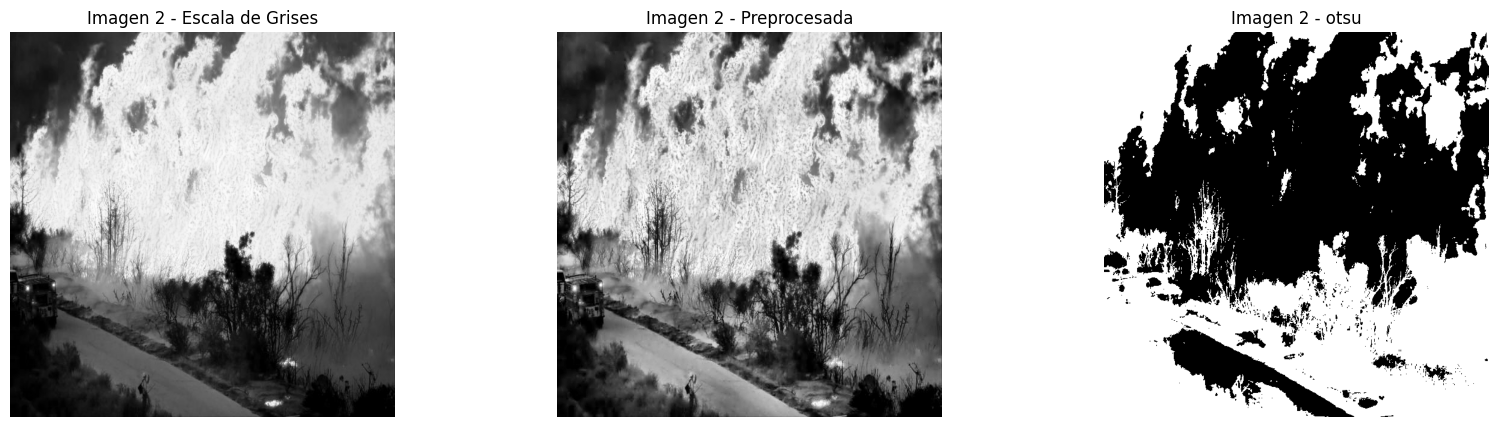

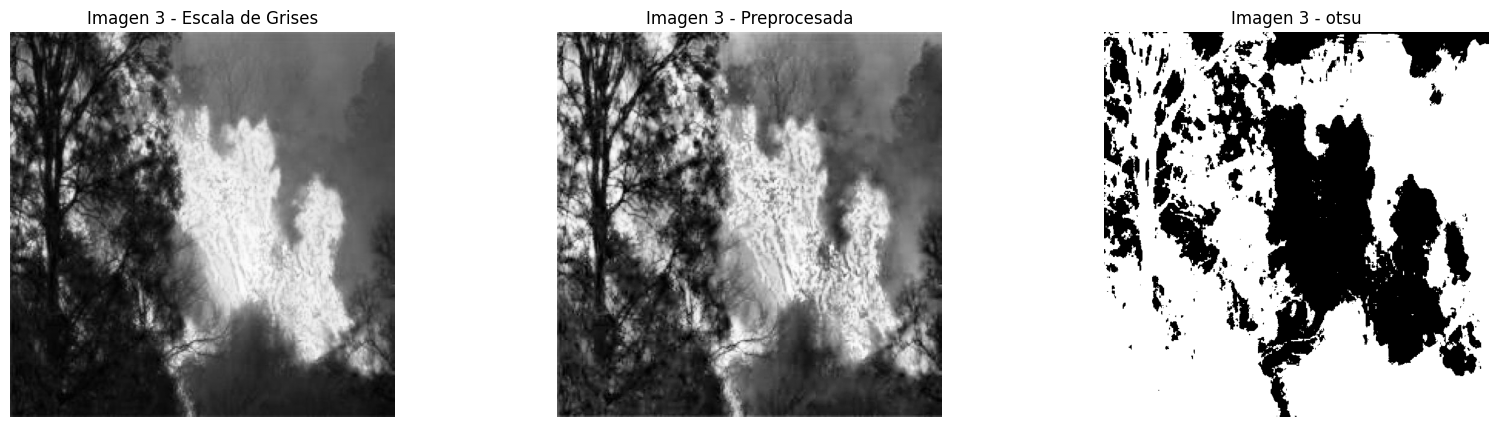

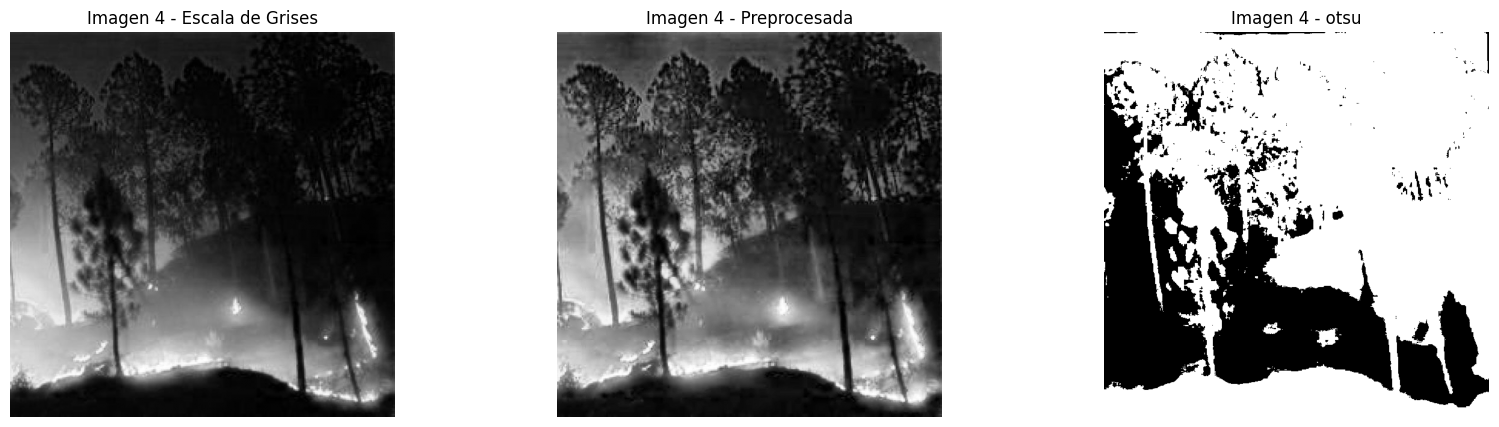

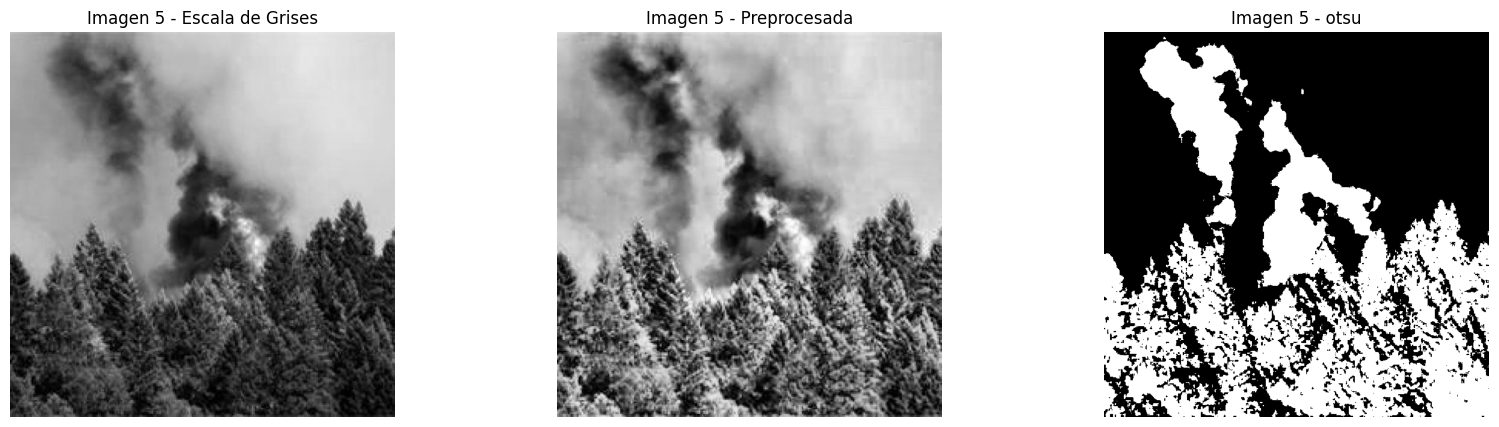

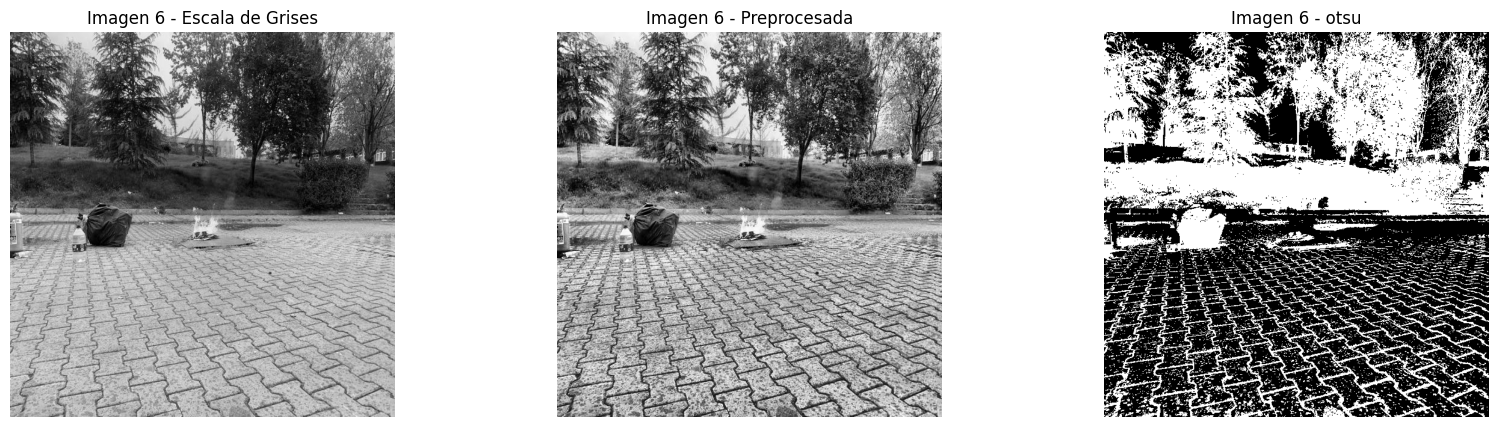

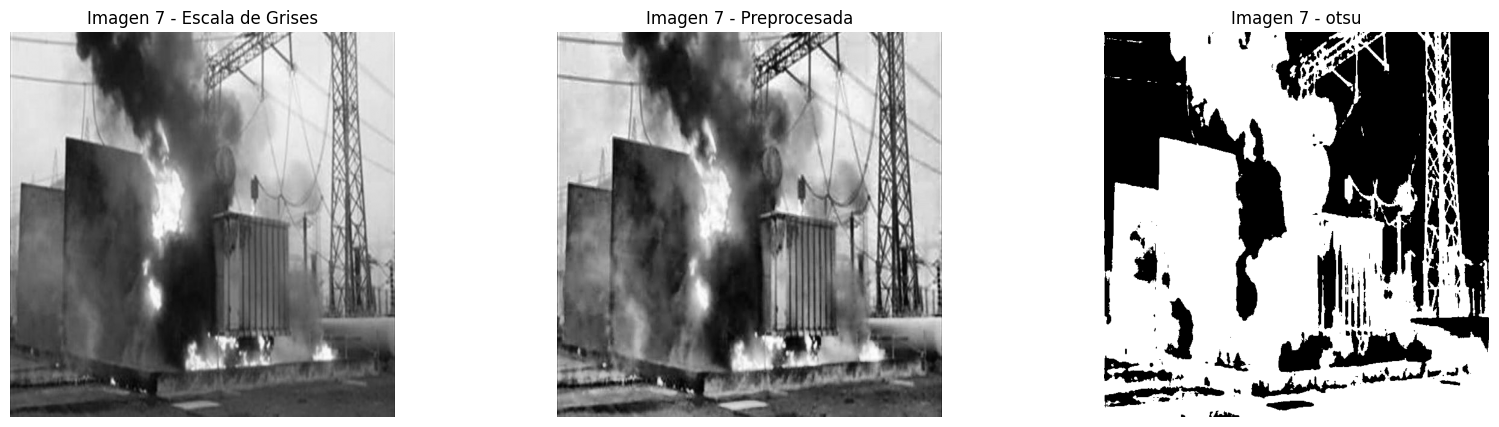

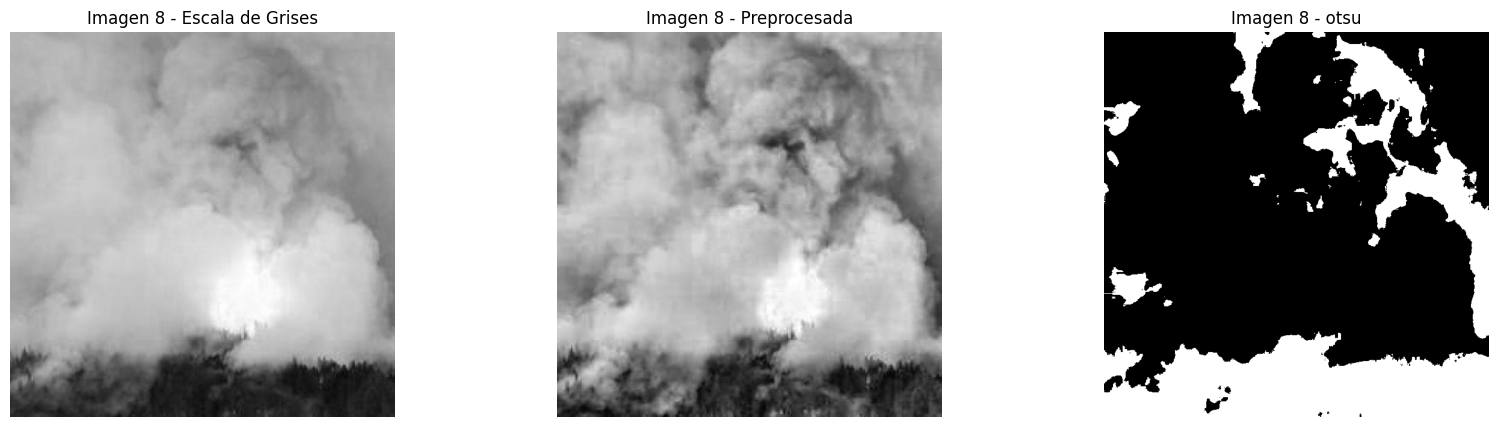

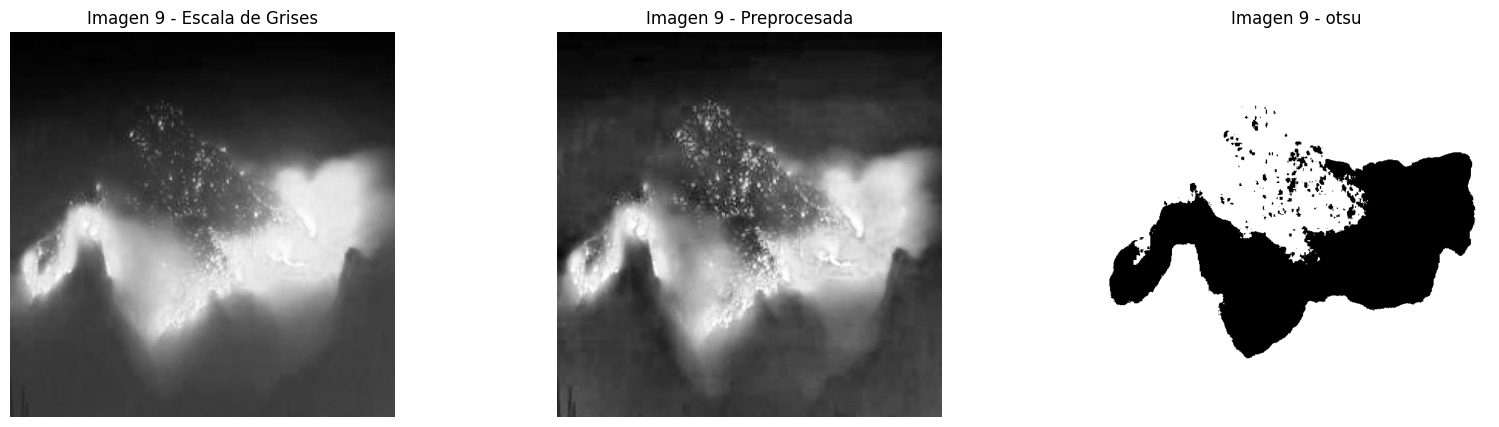

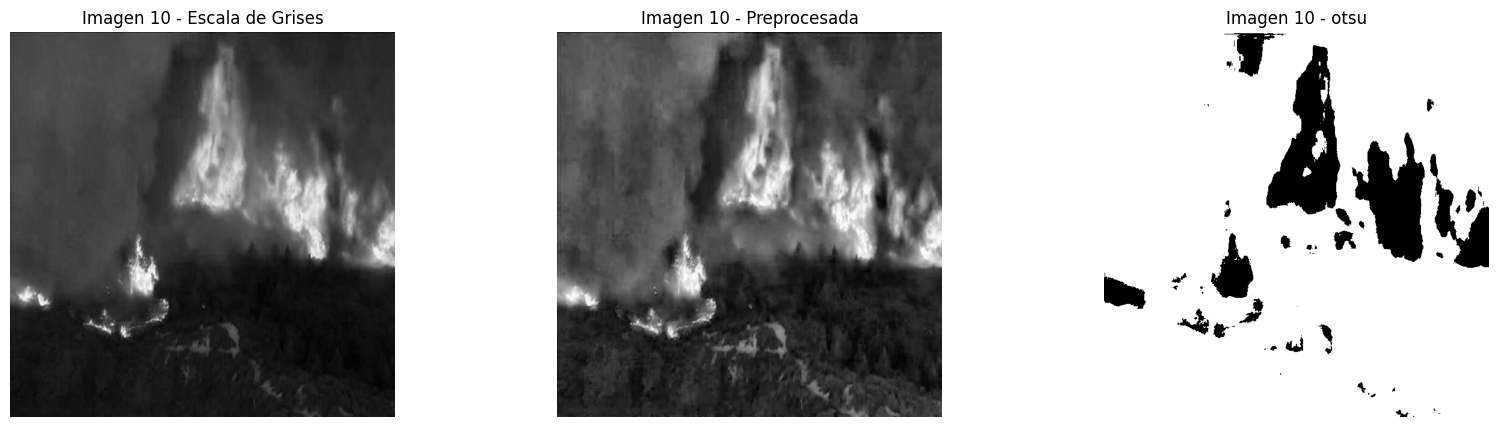

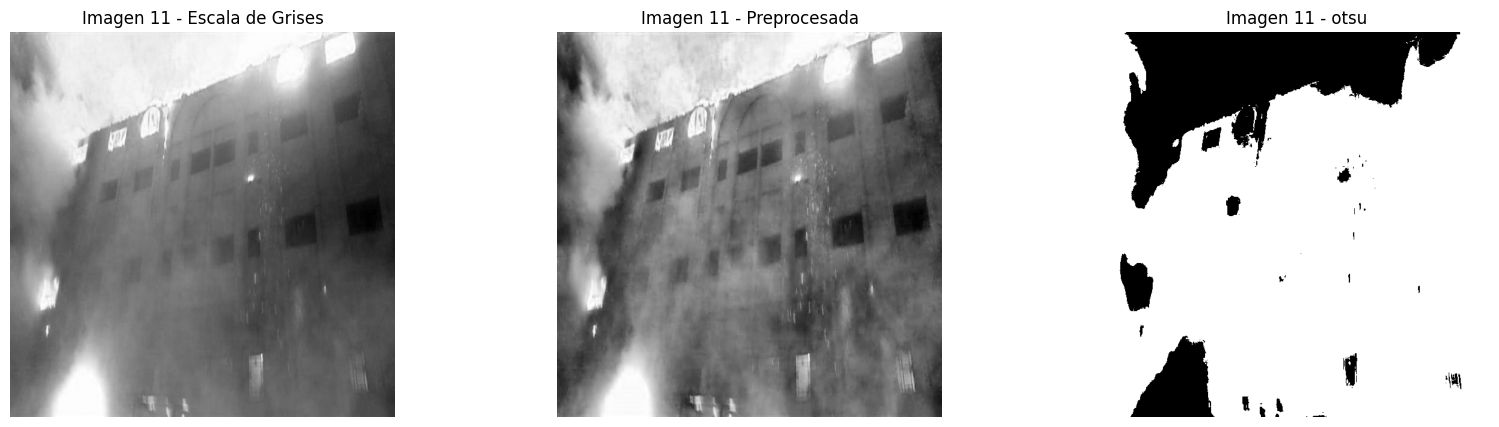

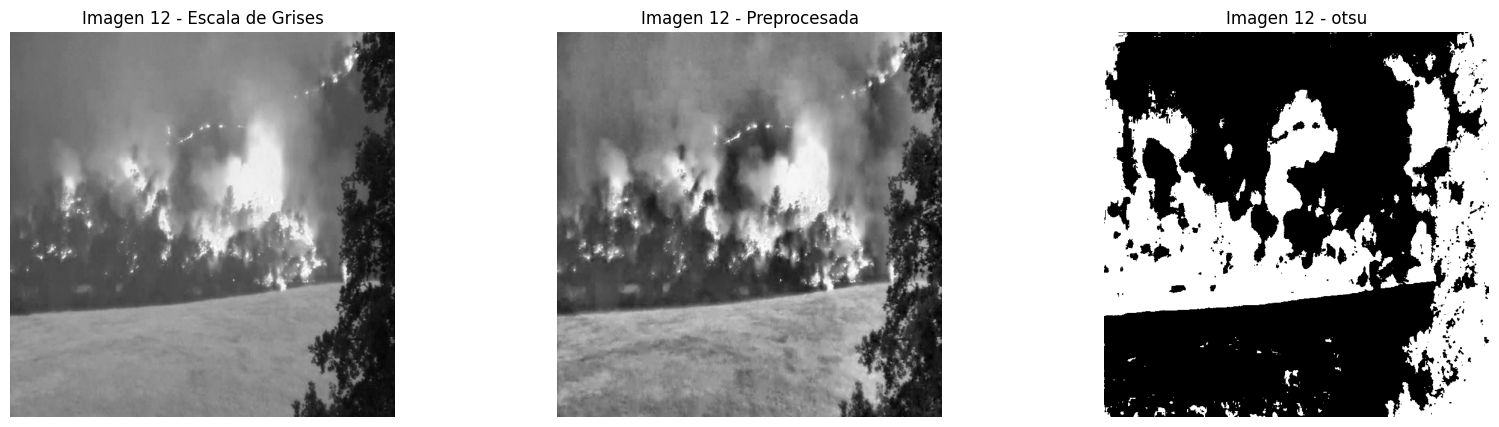

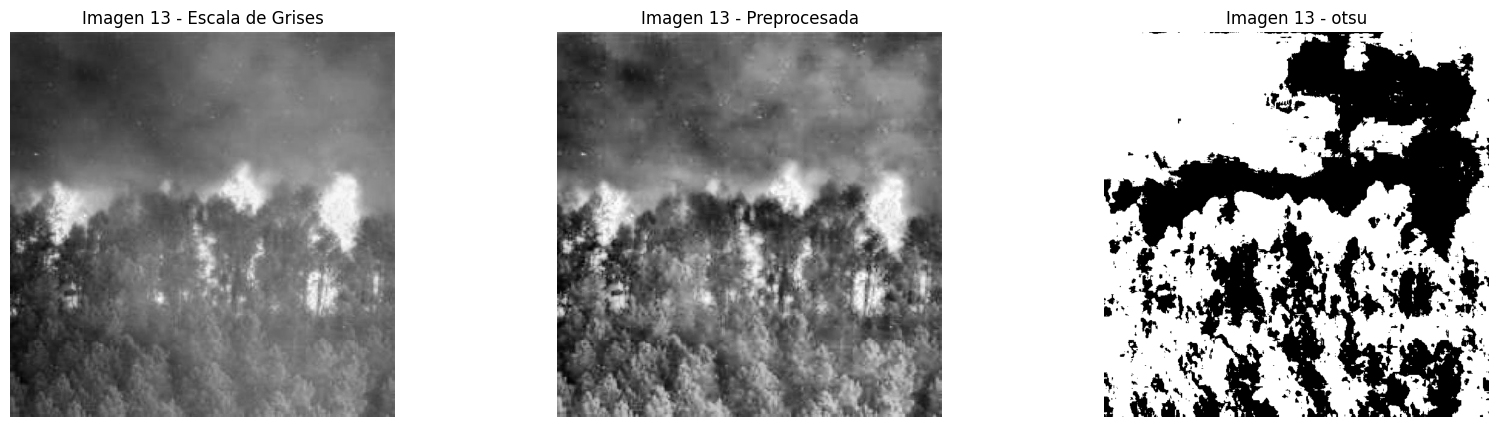

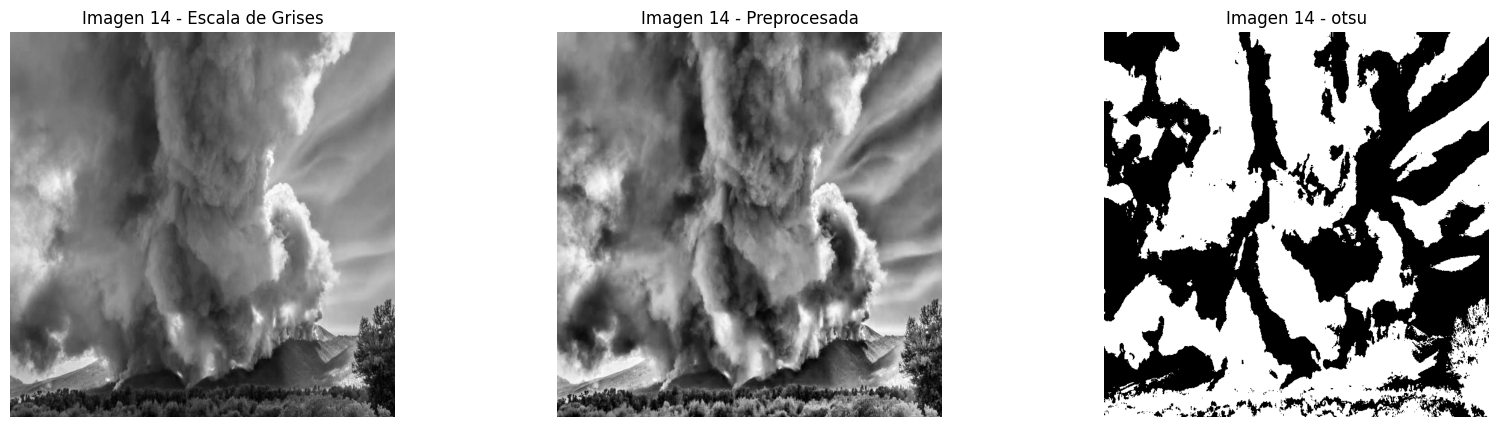

In [16]:
# Mostrar resultados, por cada imagen mostrar la original, la preprocesada y el resultado de otsu
for img_num in imagenes_rgb.keys():
    R, G, B = imagenes_rgb[img_num]
    gris = imagenes_grises[img_num]
    prepro = img_prepro[img_num]
    otsu = img_otsu[img_num][0]
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].imshow(gris, cmap='gray')
    axes[0].set_title(f'Imagen {img_num} - Escala de Grises')
    axes[0].axis('off')

    axes[1].imshow(prepro, cmap='gray')
    axes[1].set_title(f'Imagen {img_num} - Preprocesada')
    axes[1].axis('off')

    axes[2].imshow(otsu, cmap='gray')
    axes[2].set_title(f'Imagen {img_num} - otsu')
    axes[2].axis('off')

    plt.show()
        

In [20]:
for img_num, otsu in img_otsu.items():
    print(f"Imagen {img_num} - T: {otsu[1]}")

Imagen 1 - T: 121
Imagen 2 - T: 133
Imagen 3 - T: 124
Imagen 4 - T: 98
Imagen 5 - T: 125
Imagen 6 - T: 127
Imagen 7 - T: 134
Imagen 8 - T: 131
Imagen 9 - T: 122
Imagen 10 - T: 113
Imagen 11 - T: 158
Imagen 12 - T: 108
Imagen 13 - T: 117
Imagen 14 - T: 123
